# 🔬 GoogLeNet Training on C-NMC Dataset
## Cancer Cell Classification - Normal vs Leukemic

**Configuration:**
- Model: GoogLeNet (Inception v1)
- Pre-trained Weights: ✅ TRUE (ImageNet)
- Normalization: ✅ TRUE (ImageNet)
- Epochs: 20
- Batch Size: 32

---

## 📚 Step 1: Import Libraries and Setup

In [1]:
# ============================================================================
# STEP 1: Import Libraries and Setup - CPU MODE (FIXED)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ✅ FORCE CPU MODE (to avoid CUDA compatibility issues)
device = torch.device('cpu')
print(f"🖥️  Using device: {device}")
print("⚠️  Running on CPU (slower but 100% stable)")
print("💡 Training will take approximately 2-3 hours for 20 epochs")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("\n✅ All libraries imported successfully!")

🖥️  Using device: cpu
⚠️  Running on CPU (slower but 100% stable)
💡 Training will take approximately 2-3 hours for 20 epochs

✅ All libraries imported successfully!


## 📂 Step 2: Data Preparation - Create Dataset Structure

In [2]:
# ============================================================================
# STEP 2: Data Preparation
# ============================================================================

import os

# ✅ YOUR EXACT PATH
BASE_PATH = '/kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)'
ALL_PATH = os.path.join(BASE_PATH, 'all')
NORMAL_PATH = os.path.join(BASE_PATH, 'normal')

# Verify paths exist
print("🔍 Verifying dataset paths...\n")
print(f"📂 Configured Paths:")
print(f"   BASE_PATH:   {BASE_PATH}")
print(f"   ALL_PATH:    {ALL_PATH}")
print(f"   NORMAL_PATH: {NORMAL_PATH}\n")

# Check existence
assert os.path.exists(BASE_PATH), f"BASE_PATH not found: {BASE_PATH}"
assert os.path.exists(ALL_PATH), f"ALL_PATH not found: {ALL_PATH}"
assert os.path.exists(NORMAL_PATH), f"NORMAL_PATH not found: {NORMAL_PATH}"

print("✅ All paths verified!\n")

# Load image lists
all_images = [f for f in os.listdir(ALL_PATH) if f.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png'))]
normal_images = [f for f in os.listdir(NORMAL_PATH) if f.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png'))]

print(f"📊 Dataset Statistics:")
print(f"   Images in 'all' folder: {len(all_images)}")
print(f"   Images in 'normal' folder: {len(normal_images)}")

# Check for overlap
overlap = set(all_images) & set(normal_images)
print(f"   Overlapping images: {len(overlap)}")

if len(overlap) == 0:
    print(f"\n✅ Confirmed: Separate folder structure")
    print(f"   'all' folder = Leukemic cells ({len(all_images)} images)")
    print(f"   'normal' folder = Normal cells ({len(normal_images)} images)")
    folder_structure = "SEPARATE"
else:
    print(f"\n✅ Confirmed: Standard structure")
    print(f"   'all' folder = All images")
    print(f"   'normal' folder = Subset of 'all'")
    folder_structure = "STANDARD"

# Create dataframe based on structure
data_list = []

if folder_structure == "SEPARATE":
    # Leukemic images from 'all' folder
    for img in all_images:
        data_list.append({
            'image': img,
            'label': 1,
            'class': 'Leukemic',
            'folder': 'all'
        })
    
    # Normal images from 'normal' folder
    for img in normal_images:
        data_list.append({
            'image': img,
            'label': 0,
            'class': 'Normal',
            'folder': 'normal'
        })
else:
    # Standard structure
    leukemic_set = set(all_images) - set(normal_images)
    
    for img in normal_images:
        data_list.append({
            'image': img,
            'label': 0,
            'class': 'Normal',
            'folder': 'all'
        })
    
    for img in leukemic_set:
        data_list.append({
            'image': img,
            'label': 1,
            'class': 'Leukemic',
            'folder': 'all'
        })

# Create dataframe
df = pd.DataFrame(data_list)

print(f"\n✅ Dataset created with {len(df)} images")
print(f"\n📋 Class distribution:")
print(df['class'].value_counts())

print(f"\n📁 Folder distribution:")
print(df['folder'].value_counts())

print(f"\n📊 Class balance:")
class_counts = df['class'].value_counts()
total = len(df)
for class_name in ['Normal', 'Leukemic']:
    if class_name in class_counts.index:
        count = class_counts[class_name]
        percentage = (count / total) * 100
        print(f"   {class_name}: {count} ({percentage:.2f}%)")

# Test loading images from BOTH folders
print("\n🧪 Testing image loading...")

# Test Normal image
if 'Normal' in df['class'].values:
    normal_sample = df[df['class'] == 'Normal'].iloc[0]
    normal_img = normal_sample['image']
    normal_folder = normal_sample['folder']
    normal_path = os.path.join(BASE_PATH, normal_folder, normal_img)
    
    print(f"\n   Testing NORMAL image:")
    print(f"   Image: {normal_img}")
    print(f"   Folder: {normal_folder}")
    print(f"   Path: {normal_path}")
    print(f"   Exists: {os.path.exists(normal_path)}")
    
    try:
        from PIL import Image
        img = Image.open(normal_path)
        print(f"   ✅ Loaded successfully - Size: {img.size}, Mode: {img.mode}")
    except Exception as e:
        print(f"   ❌ Failed: {e}")
        raise

# Test Leukemic image
if 'Leukemic' in df['class'].values:
    leukemic_sample = df[df['class'] == 'Leukemic'].iloc[0]
    leukemic_img = leukemic_sample['image']
    leukemic_folder = leukemic_sample['folder']
    leukemic_path = os.path.join(BASE_PATH, leukemic_folder, leukemic_img)
    
    print(f"\n   Testing LEUKEMIC image:")
    print(f"   Image: {leukemic_img}")
    print(f"   Folder: {leukemic_folder}")
    print(f"   Path: {leukemic_path}")
    print(f"   Exists: {os.path.exists(leukemic_path)}")
    
    try:
        img = Image.open(leukemic_path)
        print(f"   ✅ Loaded successfully - Size: {img.size}, Mode: {img.mode}")
    except Exception as e:
        print(f"   ❌ Failed: {e}")
        raise

print("\n" + "="*70)
print("✅ STEP 2 COMPLETED SUCCESSFULLY")
print("="*70)

🔍 Verifying dataset paths...

📂 Configured Paths:
   BASE_PATH:   /kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)
   ALL_PATH:    /kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)/all
   NORMAL_PATH: /kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)/normal

✅ All paths verified!

📊 Dataset Statistics:
   Images in 'all' folder: 7272
   Images in 'normal' folder: 3389
   Overlapping images: 0

✅ Confirmed: Separate folder structure
   'all' folder = Leukemic cells (7272 images)
   'normal' folder = Normal cells (3389 images)

✅ Dataset created with 10661 images

📋 Class distribution:
class
Leukemic    7272
Normal      3389
Name: count, dtype: int64

📁 Folder distribution:
folder
all       7272
normal    3389
Name: count, dtype: int64

📊 Class balance:
   Normal: 3389 (31.79%)
   Leukemic: 7272 (68.21%)

🧪 Testing image loading...

   Testing NORMAL image:
   Image: UID_H23_5_5_hem.bmp
   Folder: normal
   Path: /kaggle/input/datasets/ima

## 🎨 Step 3: Custom Dataset Class

In [3]:
# ============================================================================
# STEP 3: Custom Dataset Class
# ============================================================================

class CNMCDataset(Dataset):
    """Custom Dataset for C-NMC - handles images in different folders"""
    
    def __init__(self, dataframe, base_path, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.base_path = base_path
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_name = row['image']
        folder = row['folder']  # 'all' or 'normal'
        
        # Build full path: base_path/folder/image
        img_path = os.path.join(self.base_path, folder, img_name)
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        label = row['label']
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

print("✅ Custom Dataset class defined (multi-folder support)!")

✅ Custom Dataset class defined (multi-folder support)!


## 🔄 Step 4: Data Transforms with Normalization (TRUE)

In [4]:
# ============================================================================
# STEP 4: Data Transforms with Normalization
# ============================================================================

# ImageNet normalization values (standard for pre-trained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # ✅ Normalization TRUE
])

# Validation/Test transforms (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # ✅ Normalization TRUE
])

print("✅ Transforms created with ImageNet normalization enabled")
print(f"   Mean: {IMAGENET_MEAN}")
print(f"   Std:  {IMAGENET_STD}")

✅ Transforms created with ImageNet normalization enabled
   Mean: [0.485, 0.456, 0.406]
   Std:  [0.229, 0.224, 0.225]


## ✂️ Step 5: Split Dataset (Train: 70%, Val: 15%, Test: 15%)

In [5]:
# ============================================================================
# STEP 5: Split Dataset (Train: 70%, Val: 15%, Test: 15%)
# ============================================================================

from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=42
)

# Second split: 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

# ✅ IMPORTANT: Reset indices for proper dataset indexing
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"📊 Dataset Split:")
print(f"   Train set: {len(train_df)} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"   Validation set: {len(val_df)} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"   Test set: {len(test_df)} images ({len(test_df)/len(df)*100:.1f}%)")

# Class distribution
print(f"\n📊 Class distribution in splits:")
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n   {split_name}:")
    print(f"   {split_df['class'].value_counts().to_dict()}")

# Folder distribution
print(f"\n📁 Folder distribution in train set:")
print(train_df['folder'].value_counts())

# Verify paths
print(f"\n🔍 Path Verification:")
for class_name in ['Normal', 'Leukemic']:
    if class_name in train_df['class'].values:
        sample = train_df[train_df['class'] == class_name].iloc[0]
        img_name = sample['image']
        folder = sample['folder']
        full_path = os.path.join(BASE_PATH, folder, img_name)
        
        print(f"\n   {class_name}:")
        print(f"   Image: {img_name}")
        print(f"   Folder: {folder}")
        print(f"   Path: {full_path}")
        print(f"   Exists: {os.path.exists(full_path)}")

# Create datasets (using BASE_PATH)
print(f"\n📦 Creating datasets...")
train_dataset = CNMCDataset(train_df, BASE_PATH, transform=train_transform)
val_dataset = CNMCDataset(val_df, BASE_PATH, transform=val_test_transform)
test_dataset = CNMCDataset(test_df, BASE_PATH, transform=val_test_transform)

# Test loading
print(f"\n🧪 Testing dataset loading...")
try:
    # Test first few samples
    for i in range(min(3, len(train_dataset))):
        sample = train_dataset[i]
        class_name = ['Normal', 'Leukemic'][sample[1]]
        print(f"   ✅ Loaded sample {i}: {class_name}, shape {sample[0].shape}")
    
    # Test one from each class
    for label, class_name in [(0, 'Normal'), (1, 'Leukemic')]:
        mask = train_df['label'] == label
        if mask.any():
            positional_idx = mask.idxmax()
            sample = train_dataset[positional_idx]
            print(f"   ✅ Loaded {class_name} sample (idx: {positional_idx})")
    
    print(f"\n   Total dataset size: {len(train_dataset)}")
    
except Exception as e:
    print(f"   ❌ Failed to load from dataset:")
    print(f"   Error: {e}")
    import traceback
    traceback.print_exc()
    raise

# Create dataloaders
BATCH_SIZE = 32

print(f"\n🔄 Creating DataLoaders...")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ DataLoaders created")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# Test batch loading
print(f"\n🧪 Testing batch loading...")
try:
    batch = next(iter(train_loader))
    print(f"✅ Successfully loaded batch")
    print(f"   Images shape: {batch[0].shape}")
    print(f"   Labels shape: {batch[1].shape}")
    
    labels = batch[1].numpy()
    normal_count = (labels == 0).sum()
    leukemic_count = (labels == 1).sum()
    print(f"   Batch contents: Normal={normal_count}, Leukemic={leukemic_count}")
    
except Exception as e:
    print(f"❌ Failed to load batch:")
    print(f"   Error: {e}")
    import traceback
    traceback.print_exc()
    raise

print("\n" + "="*70)
print("✅ STEP 5 COMPLETED - Ready for training!")
print("="*70)

📊 Dataset Split:
   Train set: 7462 images (70.0%)
   Validation set: 1599 images (15.0%)
   Test set: 1600 images (15.0%)

📊 Class distribution in splits:

   Train:
   {'Leukemic': 5090, 'Normal': 2372}

   Val:
   {'Leukemic': 1091, 'Normal': 508}

   Test:
   {'Leukemic': 1091, 'Normal': 509}

📁 Folder distribution in train set:
folder
all       5090
normal    2372
Name: count, dtype: int64

🔍 Path Verification:

   Normal:
   Image: UID_H2_28_1_hem.bmp
   Folder: normal
   Path: /kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)/normal/UID_H2_28_1_hem.bmp
   Exists: True

   Leukemic:
   Image: UID_32_13_8_all.bmp
   Folder: all
   Path: /kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)/all/UID_32_13_8_all.bmp
   Exists: True

📦 Creating datasets...

🧪 Testing dataset loading...
   ✅ Loaded sample 0: Normal, shape torch.Size([3, 224, 224])
   ✅ Loaded sample 1: Normal, shape torch.Size([3, 224, 224])
   ✅ Loaded sample 2: Normal, shape torch.Size([3,

## 🏗️ Step 6: Load GoogLeNet Model with Pre-trained Weights (TRUE)

In [6]:
# ============================================================================
# STEP 6: Load GoogLeNet with Pre-trained Weights - CPU VERSION
# ============================================================================

# Load GoogLeNet with ImageNet pre-trained weights
print("⏳ Loading GoogLeNet with pre-trained ImageNet weights...")

model = models.googlenet(weights='IMAGENET1K_V1', transform_input=False)

# Modify final layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)  # 2 classes: Normal and Leukemic

# Move model to CPU
model = model.to(device)

print("\n✅ GoogLeNet loaded successfully!")
print(f"   Pre-trained weights: TRUE (ImageNet)")
print(f"   Transform input: FALSE")
print(f"   Model moved to: {device}")
print(f"   Final layer modified for 2 classes")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Model Parameters:")
print(f"   Total: {total_params:,}")
print(f"   Trainable: {trainable_params:,}")

⏳ Loading GoogLeNet with pre-trained ImageNet weights...
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 183MB/s]



✅ GoogLeNet loaded successfully!
   Pre-trained weights: TRUE (ImageNet)
   Transform input: FALSE
   Model moved to: cpu
   Final layer modified for 2 classes

📊 Model Parameters:
   Total: 5,601,954
   Trainable: 5,601,954


## ⚙️ Step 7: Training Setup

In [7]:
# ============================================================================
# STEP 7: Training Setup
# ============================================================================

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (Adam)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler (no verbose parameter)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Number of epochs
NUM_EPOCHS = 20

print("✅ Training setup complete")
print(f"   Loss function: CrossEntropyLoss")
print(f"   Optimizer: Adam (lr=0.001)")
print(f"   Scheduler: ReduceLROnPlateau (mode=min, factor=0.5, patience=3)")
print(f"   Epochs: {NUM_EPOCHS}")

✅ Training setup complete
   Loss function: CrossEntropyLoss
   Optimizer: Adam (lr=0.001)
   Scheduler: ReduceLROnPlateau (mode=min, factor=0.5, patience=3)
   Epochs: 20


## 🔧 Step 8: Define Training and Validation Functions

In [8]:
# ============================================================================
# STEP 8: Training and Validation Functions
# ============================================================================

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        
        # Handle GoogLeNet auxiliary outputs during training
        if isinstance(outputs, tuple):
            outputs = outputs[0]  # Main output
        
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)
            
            # Handle GoogLeNet auxiliary outputs
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

print("✅ Training and validation functions defined")

✅ Training and validation functions defined


## 🚀 Step 9: Training Loop (20 Epochs)

In [9]:
# ============================================================================
# STEP 9: Training Loop (20 Epochs)
# ============================================================================

import time

# History tracking
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'learning_rate': []
}

best_val_acc = 0.0
best_epoch = 0
best_model_path = 'best_googlenet_model.pth'

print("="*70)
print("🚀 STARTING TRAINING")
print("="*70)
print(f"Configuration:")
print(f"  Model: GoogLeNet (Inception v1)")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Learning Rate: {optimizer.param_groups[0]['lr']}")
print(f"  Device: {device}")
print(f"  Train Samples: {len(train_dataset)}")
print(f"  Val Samples: {len(val_dataset)}")
print("="*70)

# Start training timer
train_start_time = time.time()

try:
    for epoch in range(NUM_EPOCHS):
        epoch_start = time.time()
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f"\n{'='*70}")
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - LR: {current_lr:.6f}")
        print(f"{'='*70}")
        
        # Train
        print("🔄 Training...")
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        print("🔄 Validating...")
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Update scheduler and track LR changes
        old_lr = current_lr
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if new_lr < old_lr:
            print(f"\n📉 Learning rate reduced: {old_lr:.6f} → {new_lr:.6f}")
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rate'].append(current_lr)
        
        # Save best model
        if val_acc > best_val_acc:
            improvement = val_acc - best_val_acc
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), best_model_path)
            best_marker = f" 🌟 NEW BEST! (+{improvement:.2f}%)"
        else:
            best_marker = ""
        
        # Calculate epoch time
        epoch_time = time.time() - epoch_start
        
        # Print epoch results
        print(f"\n📊 Epoch {epoch+1} Results:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  Best Val Acc: {best_val_acc:.2f}% (Epoch {best_epoch})")
        print(f"  Epoch Time: {epoch_time:.2f}s{best_marker}")
        print("-"*70)

except KeyboardInterrupt:
    print("\n\n⚠️  Training interrupted by user!")
    print(f"Completed {epoch+1} epochs before interruption")

except Exception as e:
    print(f"\n\n❌ Error during training:")
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

finally:
    # End training timer
    train_end_time = time.time()
    total_train_time = train_end_time - train_start_time
    
    print("\n" + "="*70)
    print("✅ TRAINING COMPLETE" if len(history['train_loss']) > 0 else "❌ TRAINING FAILED")
    print("="*70)
    print(f"⏱️  Total Time: {total_train_time:.2f} seconds ({total_train_time/60:.2f} minutes)")
    
    if len(history['train_loss']) > 0:
        print(f"📊 Training Summary:")
        print(f"  Epochs Completed: {len(history['train_loss'])}")
        print(f"  Best Validation Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})")
        print(f"  Final Train Accuracy: {history['train_acc'][-1]:.2f}%")
        print(f"  Final Val Accuracy: {history['val_acc'][-1]:.2f}%")
        print(f"  Average Epoch Time: {total_train_time/len(history['train_loss']):.2f}s")
    else:
        print("⚠️  No epochs completed - check errors above")
    print("="*70)

# Display training progression (only if training happened)
if len(history['train_loss']) > 0:
    print("\n📈 Training Progression:")
    print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'LR':<12}")
    print("-"*70)
    for i in range(len(history['train_loss'])):
        marker = " 🌟" if history['val_acc'][i] == best_val_acc else ""
        print(f"{i+1:<8} {history['train_loss'][i]:<12.4f} {history['train_acc'][i]:<12.2f} "
              f"{history['val_loss'][i]:<12.4f} {history['val_acc'][i]:<12.2f} "
              f"{history['learning_rate'][i]:<12.6f}{marker}")
    
    print("\n✅ Best model saved at: " + best_model_path)
else:
    print("\n❌ Training did not complete successfully")

🚀 STARTING TRAINING
Configuration:
  Model: GoogLeNet (Inception v1)
  Epochs: 20
  Batch Size: 32
  Learning Rate: 0.001
  Device: cpu
  Train Samples: 7462
  Val Samples: 1599

Epoch 1/20 - LR: 0.001000
🔄 Training...
🔄 Validating...

📊 Epoch 1 Results:
  Train Loss: 0.3896 | Train Acc: 83.58%
  Val Loss:   1.0663 | Val Acc:   50.09%
  Best Val Acc: 50.09% (Epoch 1)
  Epoch Time: 816.48s 🌟 NEW BEST! (+50.09%)
----------------------------------------------------------------------

Epoch 2/20 - LR: 0.001000
🔄 Training...
🔄 Validating...

📊 Epoch 2 Results:
  Train Loss: 0.3360 | Train Acc: 86.72%
  Val Loss:   0.5434 | Val Acc:   75.05%
  Best Val Acc: 75.05% (Epoch 2)
  Epoch Time: 751.37s 🌟 NEW BEST! (+24.95%)
----------------------------------------------------------------------

Epoch 3/20 - LR: 0.001000
🔄 Training...
🔄 Validating...

📊 Epoch 3 Results:
  Train Loss: 0.3110 | Train Acc: 87.50%
  Val Loss:   0.4230 | Val Acc:   83.24%
  Best Val Acc: 83.24% (Epoch 3)
  Epoch Time: 76

## 📊 Step 10: Plot Training History (Loss and Accuracy Graphs)

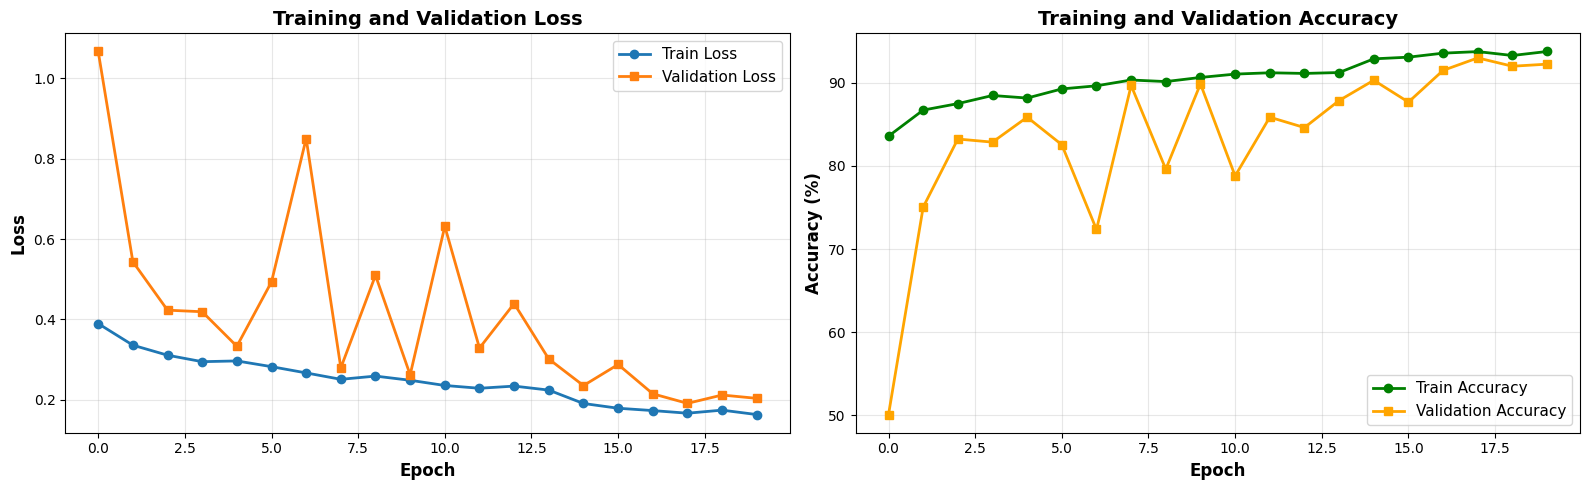

✅ Training history plots saved as 'training_history.png'


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2, markersize=6)
axes[0].plot(history['val_loss'], label='Validation Loss', marker='s', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2, markersize=6, color='green')
axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='s', linewidth=2, markersize=6, color='orange')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history plots saved as 'training_history.png'")

## 🧪 Step 11: Load Best Model and Test

In [11]:
# Load best model
model.load_state_dict(torch.load(best_model_path))
model.eval()

print("✅ Best model loaded for testing")

# Test function
def test_model(model, dataloader, device):
    """Test the model and return predictions"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            
            outputs = model(inputs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_labels), np.array(all_preds)

# Test on test set
print("\n" + "="*70)
print("🧪 TESTING ON TEST SET")
print("="*70)

test_start_time = time.time()
test_labels, test_preds = test_model(model, test_loader, device)
test_end_time = time.time()
test_time = test_end_time - test_start_time

test_acc = accuracy_score(test_labels, test_preds) * 100

print(f"\n📊 Test Accuracy: {test_acc:.2f}%")
print(f"⏱️  Test Time: {test_time:.2f} seconds")

✅ Best model loaded for testing

🧪 TESTING ON TEST SET

📊 Test Accuracy: 92.56%
⏱️  Test Time: 76.23 seconds


## 📈 Step 12: Calculate Final Train Accuracy

In [12]:
print("\n" + "="*70)
print("📈 CALCULATING FINAL TRAIN ACCURACY")
print("="*70)

train_labels, train_preds = test_model(model, train_loader, device)
final_train_acc = accuracy_score(train_labels, train_preds) * 100

print(f"\n📊 Final Train Accuracy: {final_train_acc:.2f}%")


📈 CALCULATING FINAL TRAIN ACCURACY

📊 Final Train Accuracy: 94.25%


## 📋 Step 13: Comprehensive Results Summary

In [13]:
print("\n" + "="*70)
print("📋 FINAL RESULTS SUMMARY")
print("="*70)

results_df = pd.DataFrame({
    'Metric': [
        'Model',
        'Train Accuracy (%)',
        'Validation Accuracy (%)',
        'Test Accuracy (%)',
        'Training Time (minutes)',
        'Test Time (seconds)',
        'Number of Epochs',
        'Batch Size',
        'Normalization',
        'Pre-trained Weights'
    ],
    'Value': [
        'GoogLeNet',
        f'{final_train_acc:.2f}',
        f'{best_val_acc:.2f}',
        f'{test_acc:.2f}',
        f'{total_train_time/60:.2f}',
        f'{test_time:.2f}',
        NUM_EPOCHS,
        BATCH_SIZE,
        'TRUE (ImageNet)',
        'TRUE (ImageNet)'
    ]
})

print("\n", results_df.to_string(index=False))
print("\n" + "="*70)

# Save results to CSV
results_df.to_csv('model_results.csv', index=False)
print("\n✅ Results saved to 'model_results.csv'")


📋 FINAL RESULTS SUMMARY

                  Metric           Value
                  Model       GoogLeNet
     Train Accuracy (%)           94.25
Validation Accuracy (%)           93.00
      Test Accuracy (%)           92.56
Training Time (minutes)          250.59
    Test Time (seconds)           76.23
       Number of Epochs              20
             Batch Size              32
          Normalization TRUE (ImageNet)
    Pre-trained Weights TRUE (ImageNet)


✅ Results saved to 'model_results.csv'


## 📊 Step 14: Classification Report

In [14]:
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT (Test Set)")
print("="*70)

class_names = ['Normal', 'Leukemic']
print("\n", classification_report(test_labels, test_preds, target_names=class_names, digits=4))


📊 CLASSIFICATION REPORT (Test Set)

               precision    recall  f1-score   support

      Normal     0.8900    0.8743    0.8821       509
    Leukemic     0.9418    0.9496    0.9457      1091

    accuracy                         0.9256      1600
   macro avg     0.9159    0.9119    0.9139      1600
weighted avg     0.9253    0.9256    0.9254      1600



## 🔥 Step 15: Confusion Matrix

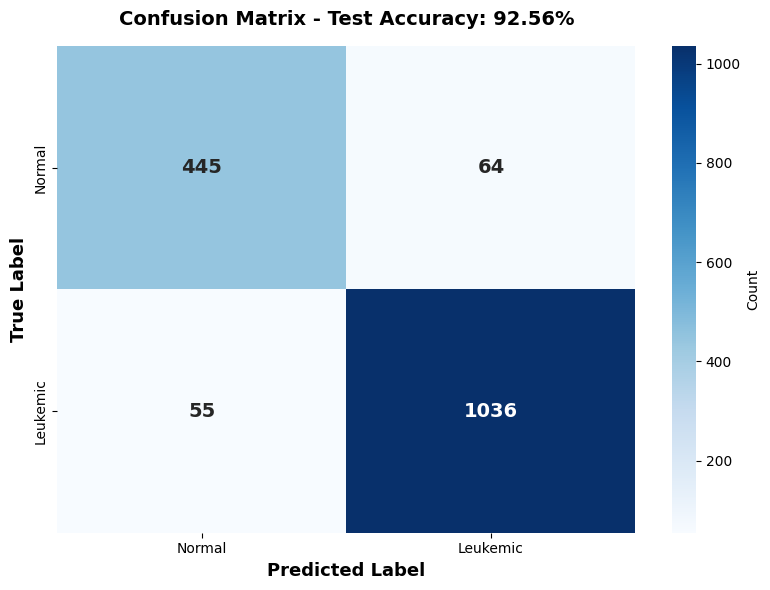

✅ Confusion matrix saved as 'confusion_matrix.png'


In [15]:
# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14, 'weight': 'bold'})
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.title(f'Confusion Matrix - Test Accuracy: {test_acc:.2f}%', 
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved as 'confusion_matrix.png'")

## 📋 Step 16: Results Table Visualization

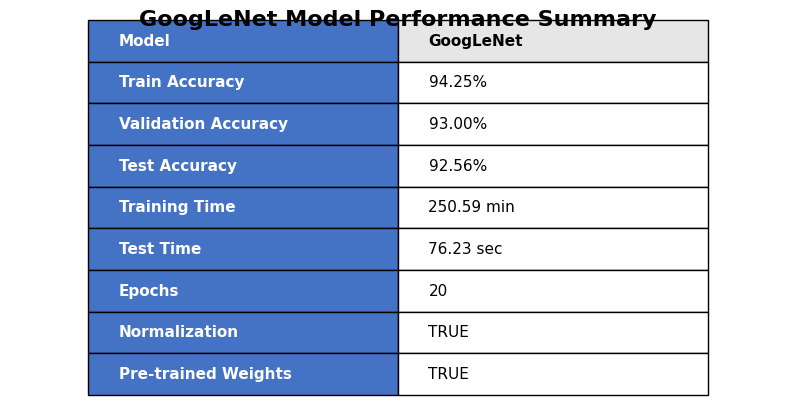

✅ Results table saved as 'results_table.png'


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

table_data = [
    ['Model', 'GoogLeNet'],
    ['Train Accuracy', f'{final_train_acc:.2f}%'],
    ['Validation Accuracy', f'{best_val_acc:.2f}%'],
    ['Test Accuracy', f'{test_acc:.2f}%'],
    ['Training Time', f'{total_train_time/60:.2f} min'],
    ['Test Time', f'{test_time:.2f} sec'],
    ['Epochs', f'{NUM_EPOCHS}'],
    ['Normalization', 'TRUE'],
    ['Pre-trained Weights', 'TRUE']
]

table = ax.table(cellText=table_data, cellLoc='left', loc='center',
                colWidths=[0.4, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(len(table_data)):
    cell = table[(i, 0)]
    cell.set_facecolor('#4472C4')
    cell.set_text_props(weight='bold', color='white')
    
    cell = table[(i, 1)]
    if i == 0:
        cell.set_facecolor('#E7E6E6')
        cell.set_text_props(weight='bold')

plt.title('GoogLeNet Model Performance Summary', 
          fontsize=16, fontweight='bold', pad=20)
plt.savefig('results_table.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Results table saved as 'results_table.png'")

## 🏆 Step 17: Best Accuracy Summary

In [17]:
print("\n" + "🏆"*35)
print("BEST ACCURACY ACHIEVED")
print("🏆"*35)

best_accuracy = max(final_train_acc, best_val_acc, test_acc)
best_set = 'Train' if best_accuracy == final_train_acc else ('Validation' if best_accuracy == best_val_acc else 'Test')

print(f"\n✨ HIGHEST ACCURACY: {best_accuracy:.2f}% on {best_set} Set")
print(f"\n📊 Breakdown:")
print(f"   • Train Accuracy:      {final_train_acc:.2f}%")
print(f"   • Validation Accuracy: {best_val_acc:.2f}%")
print(f"   • Test Accuracy:       {test_acc:.2f}%")
print(f"\n⏱️  Time Summary:")
print(f"   • Training Time: {total_train_time/60:.2f} minutes")
print(f"   • Test Time: {test_time:.2f} seconds")
print("\n" + "🏆"*35)


🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
BEST ACCURACY ACHIEVED
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆

✨ HIGHEST ACCURACY: 94.25% on Train Set

📊 Breakdown:
   • Train Accuracy:      94.25%
   • Validation Accuracy: 93.00%
   • Test Accuracy:       92.56%

⏱️  Time Summary:
   • Training Time: 250.59 minutes
   • Test Time: 76.23 seconds

🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆


## 💾 Step 18: Save Final Model

In [18]:
# Save complete model
torch.save({
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_acc': final_train_acc,
    'val_acc': best_val_acc,
    'test_acc': test_acc,
    'history': history
}, 'googlenet_complete_model.pth')

print("✅ Complete model saved as 'googlenet_complete_model.pth'")
print("\n" + "="*70)
print("🎉 ALL TASKS COMPLETED SUCCESSFULLY!")
print("="*70)
print("\n📁 Output Files Generated:")
print("   ✓ best_googlenet_model.pth - Best model weights")
print("   ✓ googlenet_complete_model.pth - Complete checkpoint")
print("   ✓ training_history.png - Loss & accuracy plots")
print("   ✓ confusion_matrix.png - Confusion matrix")
print("   ✓ results_table.png - Summary table")
print("   ✓ model_results.csv - Results in CSV format")
print("\n" + "="*70)

✅ Complete model saved as 'googlenet_complete_model.pth'

🎉 ALL TASKS COMPLETED SUCCESSFULLY!

📁 Output Files Generated:
   ✓ best_googlenet_model.pth - Best model weights
   ✓ googlenet_complete_model.pth - Complete checkpoint
   ✓ training_history.png - Loss & accuracy plots
   ✓ confusion_matrix.png - Confusion matrix
   ✓ results_table.png - Summary table
   ✓ model_results.csv - Results in CSV format

